In [ ]:
!pip install transformers datasets scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 18.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system 

In [ ]:
import pandas as pd
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
import os
os.makedirs('saved_models', exist_ok=True)


In [ ]:
import kagglehub
import os

# Download the dataset
path = kagglehub.dataset_download("datafiniti/consumer-reviews-of-amazon-products")

print("Path to dataset files:", path)

# List all files in the directory to ensure the dataset is correctly downloaded
for file in os.listdir(path):
    print(file)

# Load the data into pandas dataframes
df1 = pd.read_csv(os.path.join(path, "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv"))
df2 = pd.read_csv(os.path.join(path, "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv"))

# Check the first few rows of each dataset
print("df1 shape:", df1.shape)
print("df2 shape:", df2.shape)

# Display the first few rows of df1 to inspect
df2.head()


Path to dataset files: /kaggle/input/consumer-reviews-of-amazon-products
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv
1429_1.csv
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv
df1 shape: (5000, 24)
df2 shape: (28332, 24)


,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht..."
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht..."


#clean and preprosses

In [ ]:
# Keep only the necessary column
df1_clean = df1[['categories']].copy()
df2_clean = df2[['categories']].copy()

# Combine both datasets
df = pd.concat([df1_clean, df2_clean], ignore_index=True)

# Clean and preprocess categories
def clean_categories(x):
    if pd.isnull(x):
        return ''
    split = [cat.strip().lower().replace('>', ',') for cat in str(x).split(',')]
    return ', '.join(sorted(set(split)))

df['processed_categories'] = df['categories'].apply(clean_categories)

# Remove empty and overly generic rows
generic_terms = {'miscellaneous', 'other', 'various', 'general', 'assorted'}
df = df[df['processed_categories'] != '']
df = df[~df['processed_categories'].apply(lambda x: any(term in x for term in generic_terms))]

#  Deduplicate after cleaning
df = df.drop_duplicates(subset='processed_categories').reset_index(drop=True)

print(f"Total samples after preprocessing and deduplication: {len(df)}")


Total samples after preprocessing and deduplication: 71


##embeddings using Sentence Transformer

In [ ]:
# Create embeddings using Sentence Transformer
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(df['processed_categories'].tolist(), show_progress_bar=True)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

#find the best kmean and Perform clustering

For k=4, silhouette score: 0.2194
For k=5, silhouette score: 0.2419
For k=6, silhouette score: 0.2492

Best number of clusters: 6 with silhouette score: 0.2492


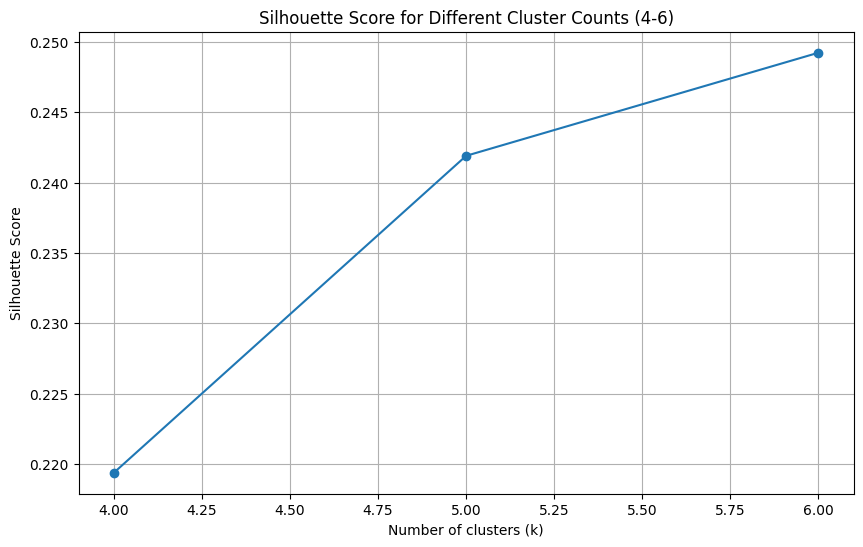

In [ ]:
# Try clustering with 4 to 6 clusters
k_range = range(4, 7)  # Try clustering with 4 to 6 clusters

silhouette_scores = []

# Find optimal number of clusters in the new range
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(embeddings)
    score = silhouette_score(embeddings, clusters)
    silhouette_scores.append(score)
    print(f"For k={k}, silhouette score: {score:.4f}")

# Choose the best k based on silhouette score
best_k = k_range[np.argmax(silhouette_scores)]
best_score = silhouette_scores[np.argmax(silhouette_scores)]
print(f"\nBest number of clusters: {best_k} with silhouette score: {best_score:.4f}")

# Perform clustering with the optimal k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(embeddings)

# Optionally, visualize the silhouette scores for clusters
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, 'o-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different Cluster Counts (4-6)')
plt.grid(True)
plt.savefig('silhouette_scores_4_6.png')
plt.show()



/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


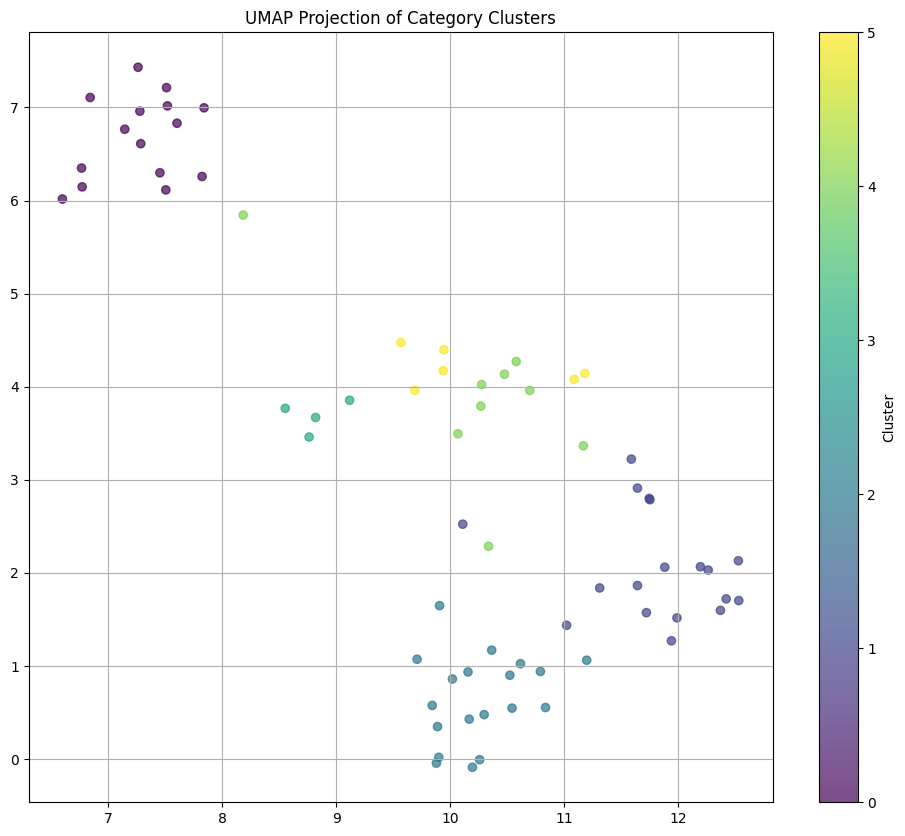

In [ ]:
# Visualize with UMAP
import umap
reducer = umap.UMAP(random_state=42)
umap_embeddings = reducer.fit_transform(embeddings)

plt.figure(figsize=(12, 10))
plt.scatter(
    umap_embeddings[:, 0],
    umap_embeddings[:, 1],
    c=df['cluster'],
    cmap='viridis',
    alpha=0.7
)
plt.colorbar(label='Cluster')
plt.title('UMAP Projection of Category Clusters')
plt.grid(True)
plt.show()



##Preview the resulting clusters

In [ ]:
# Preview the resulting clusters
print("\n--- Cluster Analysis ---")
for cluster in range(best_k):
    cluster_df = df[df['cluster'] == cluster]
    print(f"\n Cluster {cluster} ({len(cluster_df)} items)")

    # Display sample categories
    if len(cluster_df) > 0:
        sample_size = min(10, len(cluster_df))
        samples = cluster_df['processed_categories'].sample(sample_size).tolist()
        for i, sample in enumerate(samples, 1):
            print(f"{i}. {sample}")

    # Get most common category terms
    all_terms = []
    for cats in cluster_df['processed_categories']:
        all_terms.extend([term.strip() for term in cats.split(',')])

    term_counts = pd.Series(all_terms).value_counts().head(5)
    print("\nMost common category terms:")
    for term, count in term_counts.items():
        print(f"- {term}: {count}")



--- Cluster Analysis ---

 Cluster 0 (15 items)
1. amazon, amazon echo, amazon home, digital device 3, electronics features, home & tools, home improvement, smart home, smart home automation, smart hub & kits, speakers, tvs entertainment, virtual assistant speakers, voice assistants, wireless speakers
2. amazon, amazon devices, amazon smp, consumer electronics, digital device 4, electronics, electronics deals, featured brands, fire tv, internet & media streamers, see more amazon fire tv with alexa voice remote digital..., streaming devices, streaming media players, tv, tv & video, tvs & home theater, tvs entertainment, video & home audio, video devices & tv tuners
3. amazon, amazon echo, amazon home, bluetooth speakers, digital device 3, electronics, electronics features, home & outdoors, home & tools, home improvement, networking, new networking, smart home, smart home automation, smart hub & kits, speakers, speakers & audio systems, tvs entertainment, virtual assistant speakers, vir

In [ ]:
df['cluster'] = kmeans.fit_predict(embeddings)


##Define human-readable labels for each cluster

In [ ]:

cluster_labels = {
    0: 'Amazon Echo & Smart Speakers',
    1: 'Kindle E-readers',
    2: 'Fire Tablets',
    3: 'Pet Crates & Supplies',
    4: 'Tech Accessories',
    5: 'Home/Office Essentials'
}
# Create a new column with the cluster label
df['cluster_label'] = df['cluster'].map(cluster_labels)


##predictions

In [ ]:
def predict_cluster_label(category_string):
    """
    Predicts the cluster label for a new input category string.
    """
    if not category_string:
        return "Invalid input (empty string)"

    # Clean and preprocess the input (same as you did for the dataset)
    processed = ', '.join(set([cat.strip() for cat in str(category_string).split(',')]))

    # Create embedding
    embedding = model.encode([processed])

    # Predict cluster
    cluster_id = kmeans.predict(embedding)[0]

    # Return human-readable label
    return cluster_labels.get(cluster_id, f"Cluster {cluster_id}")


In [ ]:
test_category = "This Kindle e-reader offers a glare-free display and adjustable lighting for a comfortable reading experience, even in direct sunlight. With a vast library of books available for download, it's perfect for avid readers on the go."
predicted_label = predict_cluster_label(test_category)
print(f"Predicted label: {predicted_label}")


Predicted label: Kindle E-readers


In [ ]:
def explain_prediction(category_string, top_n=5):
    """
    Predicts the cluster label for a new category string,
    and prints sample entries from that cluster for debugging.
    """
    if not category_string:
        print("Invalid input (empty string)")
        return

    # Clean the input like the training data
    processed = ', '.join(set([cat.strip() for cat in str(category_string).split(',')]))
    embedding = model.encode([processed])
    cluster_id = kmeans.predict(embedding)[0]
    label = cluster_labels.get(cluster_id, f"Cluster {cluster_id}")

    print(f"\n Predicted Cluster ID: {cluster_id}")
    print(f"Predicted Label: {label}")
    print(f"Top {top_n} examples from this cluster:\n")

    cluster_df = df[df['cluster'] == cluster_id]
    samples = cluster_df['processed_categories'].sample(min(top_n, len(cluster_df)), random_state=42).tolist()
    for i, sample in enumerate(samples, 1):
        print(f"{i}. {sample}")

    return label


In [ ]:
explain_prediction("Kindle E-readers")



 Predicted Cluster ID: 1
Predicted Label: Kindle E-readers
Top 5 examples from this cluster:

1. all tablets, amazon, computers, computers & tablets, computers/tablets & networking, e-readers, e-readers & accessories, electronics, electronics features, ipad & tablets, ipad accessories, ipads tablets, kindle e-readers, tablets, tablets & e-readers, tablets & ebook readers, used:computers accessories, used:tablets
2. amazon book reader accessory, amazon device accessories, amazon devices, amazon devices & accessories, cables & chargers, cell phone accessories, cell phone batteries & power, cell phones, chargers & adapters, chargers adapters, computers & accessories, computers features, digital device accessory, electrical, electronics, electronics features, featured brands, fire (5th generation) accessories, fire tablet accessories, home, home improvement, kindle fire (2nd generation) accessories, kindle store, power adapters & cables, power adapters cables, tablet & e-reader accessorie

'Kindle E-readers'

##saving the file for later using

In [ ]:
import joblib
import json
import os
import shutil

# Save the KMeans model
joblib.dump(kmeans, 'saved_models/kmeans_model.joblib')

# Save the SentenceTransformer model name
with open('saved_models/sentence_transformer_name.txt', 'w') as f:
    f.write('all-MiniLM-L6-v2')  # Adjust if you used a different model

# Save cluster information
cluster_info = {}
for cluster in range(best_k):
    cluster_df = df[df['cluster'] == cluster]

    # Get most common category terms
    all_terms = []
    for cats in cluster_df['processed_categories']:
        all_terms.extend([term.strip() for term in cats.split(',')])

    term_counts = pd.Series(all_terms).value_counts().head(10).to_dict()
    cluster_info[str(cluster)] = {
        'size': len(cluster_df),
        'top_terms': term_counts
    }

# Save cluster info as JSON
with open('saved_models/cluster_info.json', 'w') as f:
    json.dump(cluster_info, f, indent=2)

# Save the processed categories dataframe with cluster assignments
df.to_csv('saved_models/clustered_categories.csv', index=False)

